In [21]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data = pd.read_csv('../datasets/rs_lettland.csv')
len(data)

1900

In [23]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['target_instances', 'd', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [24]:
mlp_data = pd.read_csv('../results/MLP_ablation_friedman.csv', index_col = [0])
mlp_data['method'] = 'Finetuned MLP'
print(len(mlp_data))
mlp_data = mlp_data.drop_duplicates(subset = ['seed', 'target_instances', 'd', 'base_lr',
       'fine_tuning_lr', 'dropout_rate', 'batch_norm'], keep='first')
print(len(mlp_data))

tradaboost_data = pd.read_csv('../results/trada_ablation_friedman.csv')
tradaboost_data['method'] = 'TradaBoost.R2'
tradaboost_data = tradaboost_data.drop_duplicates()
print(len(tradaboost_data))

2407
2396
11250


3750


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_18752\4113851197.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_18752\4113851197.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = ' Naïve XGBoost'


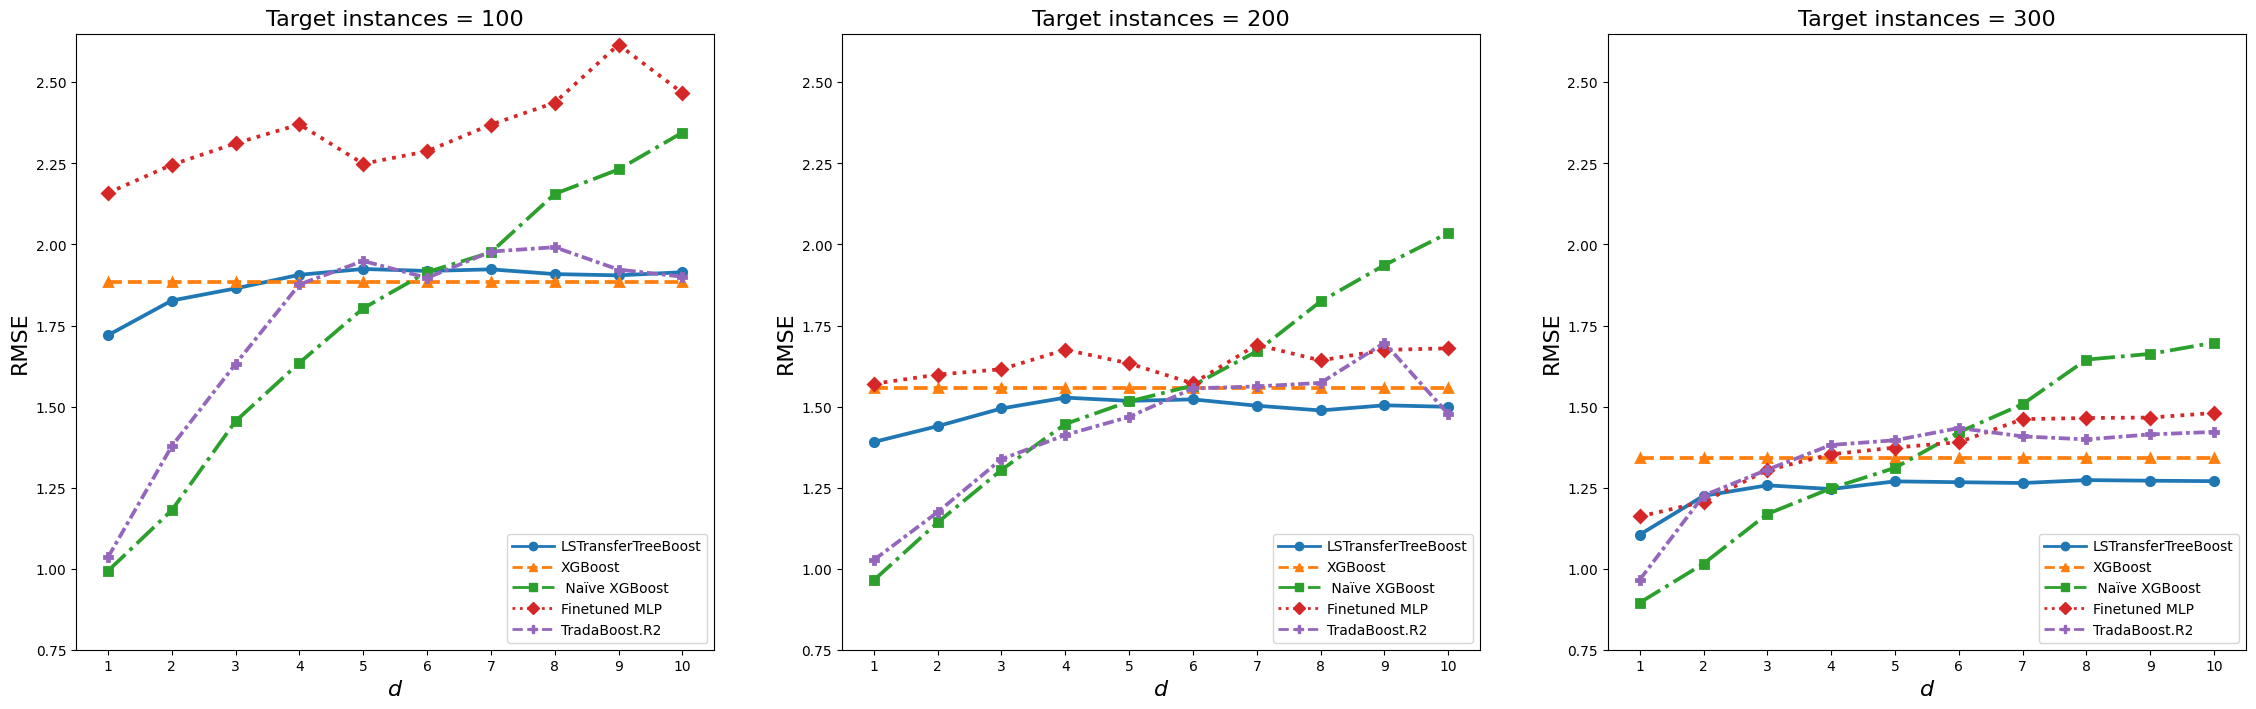

In [25]:
target_instances = 300
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'../results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)
data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
xgboost_data['method'] = 'XGBoost'
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy['method'] = ' Naïve XGBoost'

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)
"""

best_naive_transfer_with_dummy, _ = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)


best_mlp, _ = topk_per_d_per_method(
    mlp_data,
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)


best_tradaboost, k = topk_per_d_per_method(
    tradaboost_data,
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=5
)
print(len(tradaboost_data[tradaboost_data['target_instances'] == 300]))

target_instances_list = [100,200,300]
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
i=0
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
for target_instances in target_instances_list:
    plt.subplot(1,3,i+1)
    dat = df[df['target_instances'] == target_instances]
    sns.pointplot(data = dat, x = 'd', y = 'rmse', hue = 'method',  errorbar=None, 
                    markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])
   
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.gca().set_title(f'Target instances = {target_instances}', fontsize=16)
    #plt.ylabel('RMSE')
    #plt.title(f'Target instances = {target_instances}')
    plt.ylim([0.75,2.65])
    i+=1
plt.savefig('vizes/friedman.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()




In [26]:
best_params_for_us

,target_instances,d,v,source_tree_size,target_tree_size,m_0,k,avg_rmse,avg_mae,n_seeds,seed,method,val_rmse,val_mae,rmse,mae
3225,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,1,LSTransferTreeBoost,1.068126,0.837024,1.075921,0.844770
3321,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,4,LSTransferTreeBoost,1.015718,0.790704,1.006120,0.789023
3257,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,2,LSTransferTreeBoost,1.292635,1.015985,1.301308,1.025037
3353,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,5,LSTransferTreeBoost,1.220868,0.964870,1.154014,0.911733
3289,300,1,0.1,2,1,0.9,0.01,1.127009,0.887737,5,3,LSTransferTreeBoost,1.037696,0.830100,0.987166,0.790522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,2,LSTransferTreeBoost,1.728180,1.383653,1.794042,1.422162
1531,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,3,LSTransferTreeBoost,2.013109,1.612986,1.946269,1.592927
1595,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,5,LSTransferTreeBoost,1.805269,1.402929,1.735189,1.337689
1563,100,10,0.1,2,1,0.9,0.05,1.913033,1.522366,5,4,LSTransferTreeBoost,2.020507,1.613152,2.019286,1.630191


C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_18752\2120377737.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xgboost_data['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_18752\2120377737.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'


3750


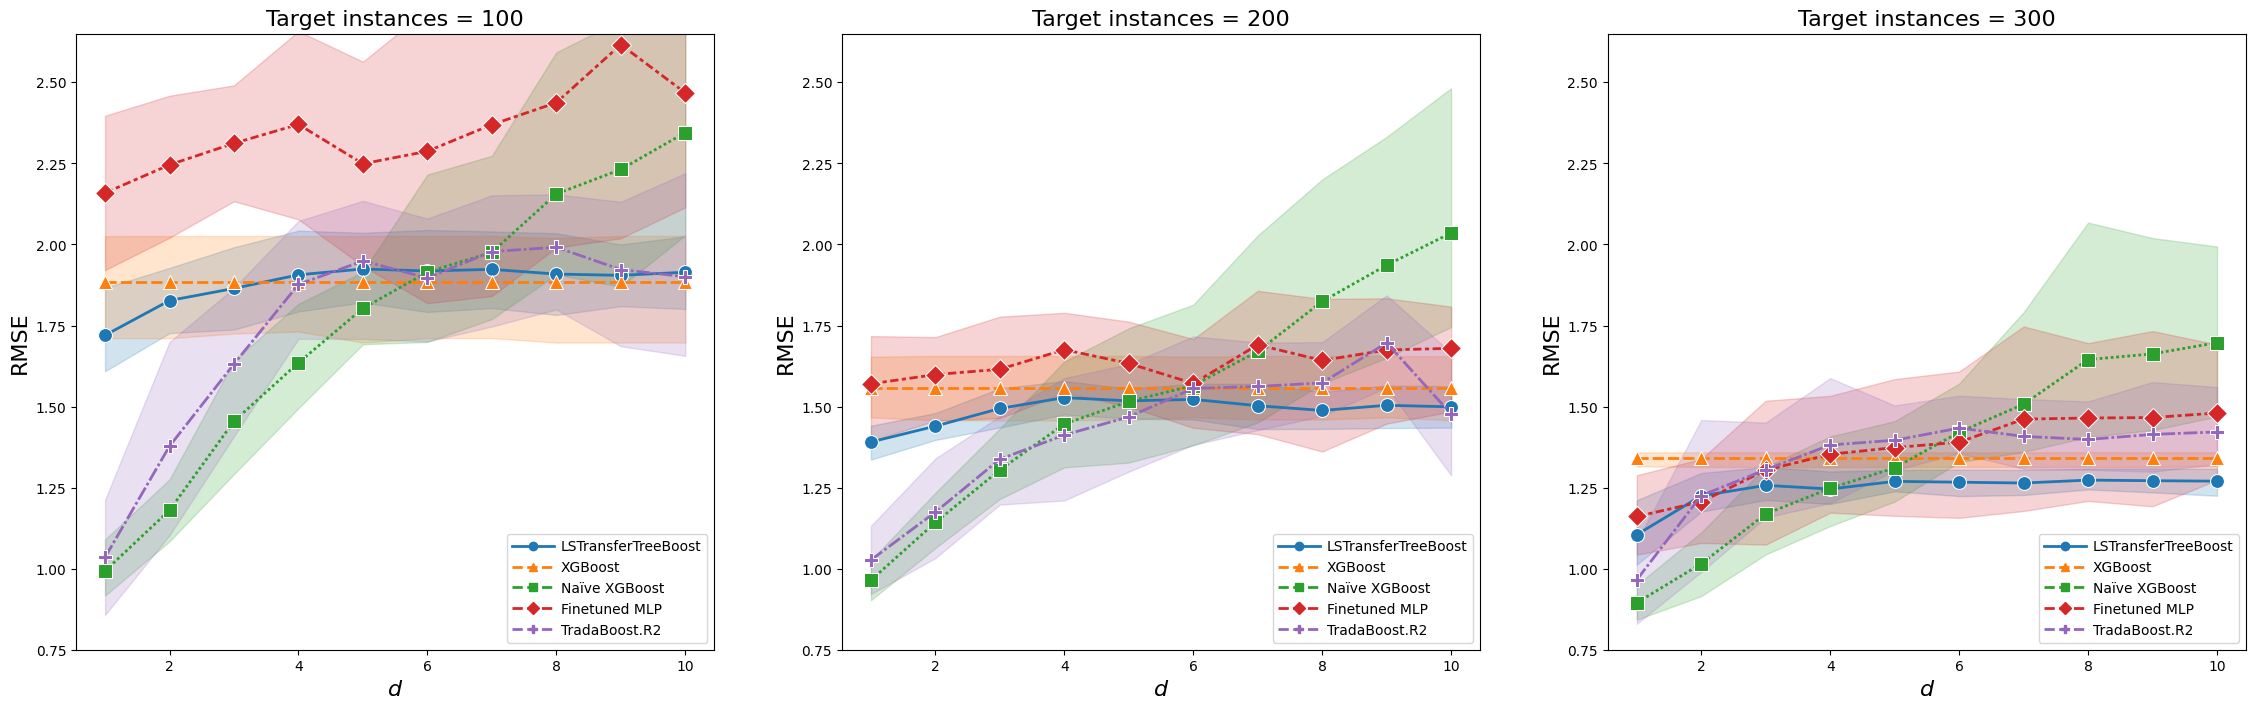

In [28]:
target_instances = 300
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'../results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)
data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
xgboost_data['method'] = 'XGBoost'
naive_transfer_data = data[data['method'] == 'xgboost_naive_transfer']
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)

"""
best_naive_transfer, _ = topk_per_d_per_method(
    naive_transfer_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)
"""

best_naive_transfer_with_dummy, _ = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_instances', 'd', 'v', 'target_tree_size'], k=5
)


best_mlp, _ = topk_per_d_per_method(
    mlp_data,
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=5
)


best_tradaboost, k = topk_per_d_per_method(
    tradaboost_data,
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=5
)
print(len(tradaboost_data[tradaboost_data['target_instances'] == 300]))

target_instances_list = [100,200,300]
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_naive_transfer])
df = pd.concat([df, best_naive_transfer_with_dummy])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])
i=0
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
for target_instances in target_instances_list:
    plt.subplot(1,3,i+1)
    dat = df[df['target_instances'] == target_instances].copy()
    # pick markers for your methods
    marker_dict = {
        'LSTransferTreeBoost': 'o',
        'XGBoost': '^',
        'Naïve XGBoost': 's',
        'Finetuned MLP': 'D',
        'TradaBoost.R2': 'P'
    }

    linestyles_dict = {
        'LSTransferTreeBoost': '-',
        'XGBoost': '--', 
        'Naïve XGBoost': '-.', 
        'Finetuned MLP': ':', 
        'TradaBoost.R2': (0, (3, 1, 1, 1)),
    }

    linestyles_dict=['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    
    sns.lineplot(
        data=dat,
        x='d', y='rmse', hue='method',
        style='method',                # needed to activate markers/dashes mapping
        markers=marker_dict,            # adds shaded confidence intervals
        linewidth=2,
        markersize=10,
        errorbar='ci'
    )
   
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.gca().set_title(f'Target instances = {target_instances}', fontsize=16)


    #plt.ylabel('RMSE')
    #plt.title(f'Target instances = {target_instances}')
    plt.ylim([0.75,2.65])
    i+=1
plt.savefig('vizes/friedman_ci.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()


